In [8]:

import os
import cv2
import yaml
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches



In [11]:

yaml_path = '../data/raw/data.yaml'

with open(yaml_path, 'r') as file:
    data_config = yaml.safe_load(file)

# We need the YAML for the class names!
class_names = data_config['names']
print(f"Classes to detect: {class_names}")


train_img_dir = '../data/raw/train/images'
train_label_dir = '../data/raw/train/labels'

print(f"Image Directory set to: {train_img_dir}")

Classes to detect: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
Image Directory set to: ../data/raw/train/images


In [13]:

def plot_mri_with_boxes(img_dir, label_dir, class_names, num_images=4):
    all_images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    selected_images = random.sample(all_images, num_images)
    
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    colors = ['#FF3838', '#2C99A8', '#FF701F'] 
    
    for ax, img_name in zip(axes, selected_images):
        img_path = os.path.join(img_dir, img_name)
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        ax.imshow(img)
        ax.axis('off')
        
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_c, y_c, box_w, box_h = map(float, parts[1:])
                    
                    x_min = int((x_c - box_w / 2) * w)
                    y_min = int((y_c - box_h / 2) * h)
                    color = colors[class_id % len(colors)]
                    
                    rect = patches.Rectangle((x_min, y_min), int(box_w * w), int(box_h * h), 
                                             linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x_min, y_min - 5, class_names[class_id], color='white', 
                            fontsize=10, bbox=dict(facecolor=color, edgecolor='none', alpha=0.8))
                    
        ax.set_title(f"Image: {img_name}", fontsize=10)

    plt.tight_layout()
    plt.show()




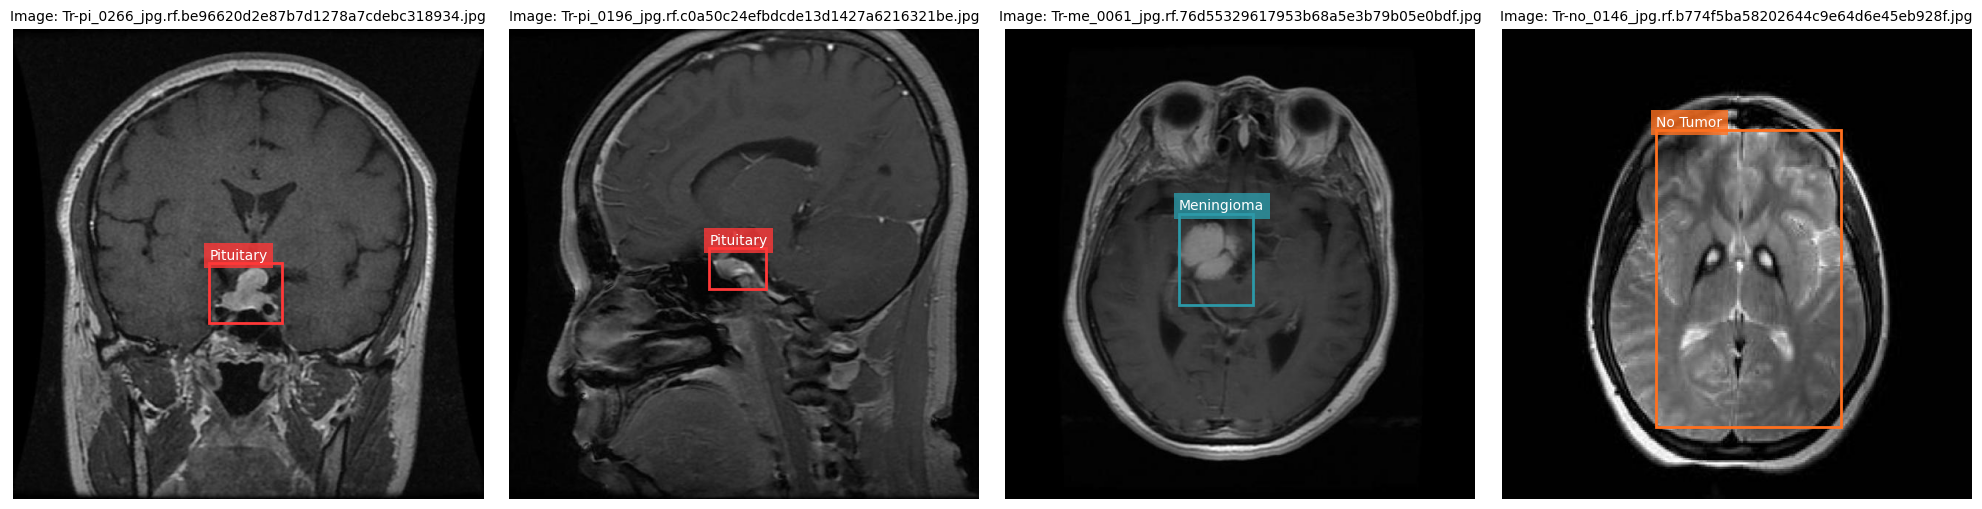

In [14]:
plot_mri_with_boxes(train_img_dir, train_label_dir, class_names, num_images=4)